In [1]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
STATE_NAMES = ["continuous", "fragmented", "stationary"]

Load data

In [2]:
mouse_id = "99b"
sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
nrem = sleep[sleep['state'] == 'nrem']

order = np.argsort(turn_units['turn_index'].values)

virtual_hds = []
states = []
for i, ep in enumerate(nrem):
    decoded = nap.load_file(INTERIM_DIR / mouse_id / f"{mouse_id}_{i}.npz")
    states_i = nap.TsdFrame(t=decoded.t, d=decoded.values[:, :3], columns=STATE_NAMES)
    vh = nap.Tsd(t=decoded.t, d=decoded.values[:, 3])
    states.append(states_i)
    virtual_hds.append(vh)

states = np.concatenate(states)
# Convert to Cartesian coordinates
angles = np.deg2rad(np.concatenate(virtual_hds))
virtual_hd = np.column_stack([np.sin(angles), np.cos(angles)])
head_direction = np.deg2rad(head_direction)
head_direction = np.column_stack([np.sin(head_direction), np.cos(head_direction)])

In [3]:
sta_awake = nap.compute_event_triggered_average(head_direction, turn_units, binsize=1, window=(-500, 500), time_unit='ms')
sta_nrem = nap.compute_event_triggered_average(virtual_hd, turn_units, binsize=1, window=(-500, 500), time_unit='ms')

In [5]:
sta_awake = nap.TsdFrame(t=sta_awake.t, d=np.rad2deg(np.arctan2(sta_awake[:, :, 0].d, sta_awake[:, :, 1].d)))
sta_nrem = nap.TsdFrame(t=sta_nrem.t, d=np.rad2deg(np.arctan2(sta_nrem[:, :, 0].d, sta_nrem[:, :, 1].d)))

In [27]:
sta_awake.save(INTERIM_DIR / mouse_id / "sta_awake.npz")
sta_nrem.save(INTERIM_DIR / mouse_id / "sta_nrem.npz")

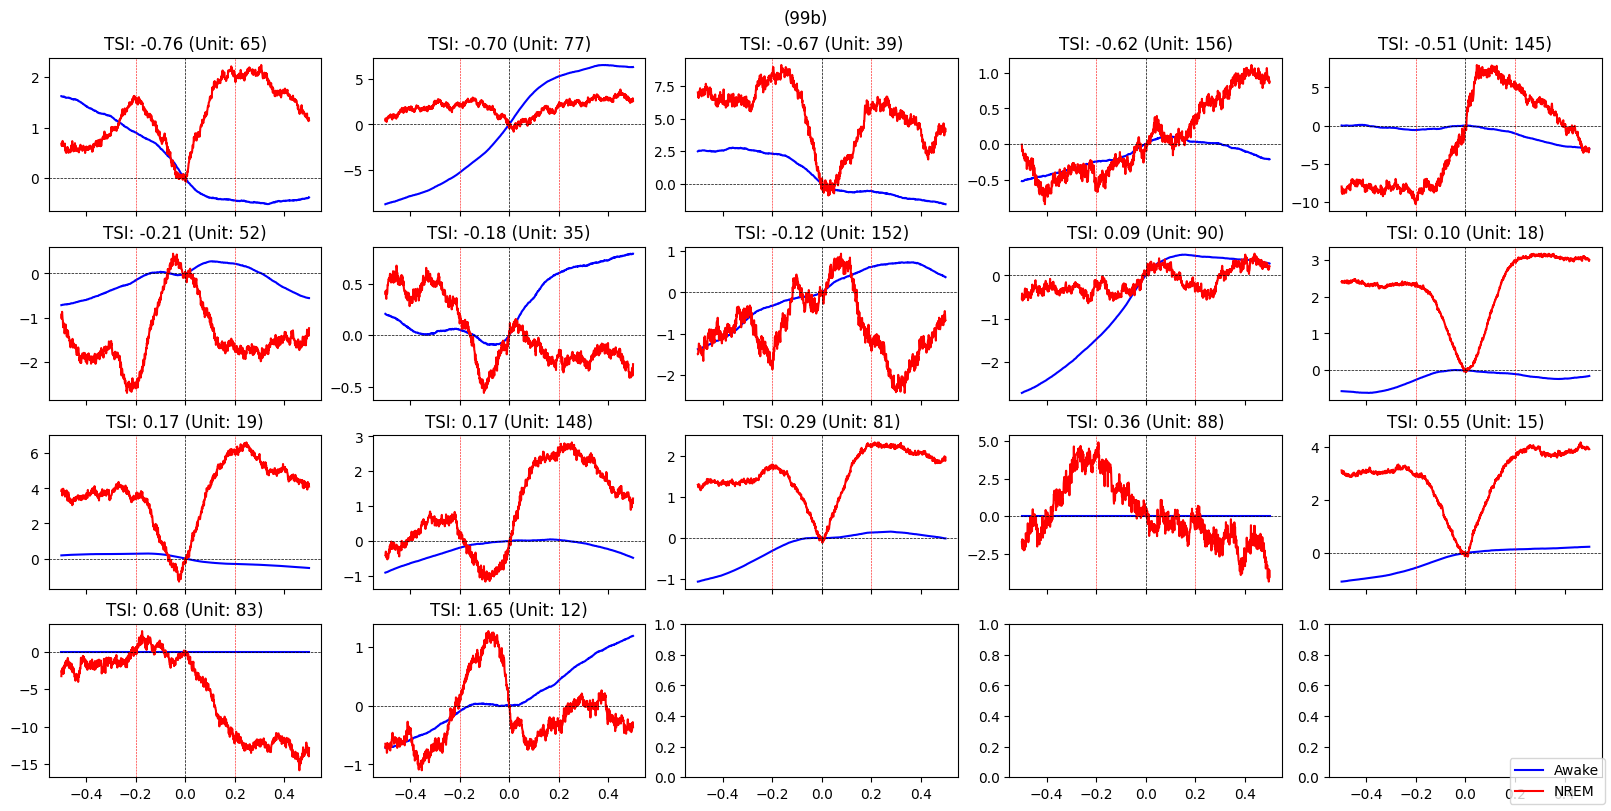

In [25]:
ncols = 5
nrows = int(np.ceil(sta_awake.shape[1] / ncols))

f, axs = plt.subplots(
    nrows, ncols,
    figsize=(16, 8),
    sharex=True,
    # sharey=True,
    constrained_layout=True,
    )

axs = axs.flatten()
for i, idx in enumerate(order):
    uid = turn_units.index[idx].item()
    ax = axs[i]

    zero_idx = np.where(sta_awake.index == 0)[0].item()
    for sta, color in zip([sta_awake, sta_nrem], ['b', 'r']):
        baseline = sta[zero_idx, :]
        sta_norm = sta - baseline
        ax.plot(sta_norm[:, idx], color=color)
    
    ax.set_title(f"TSI: {turn_units['turn_index'].values[idx]:.2f} (Unit: {uid})")
    
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax.axvline(0.2, color='r', linestyle='--', linewidth=0.4)
    ax.axvline(-0.2, color='r', linestyle='--', linewidth=0.4)

f.legend(['Awake', 'NREM'], loc='lower right')
f.suptitle(f"({mouse_id})")
plt.show()

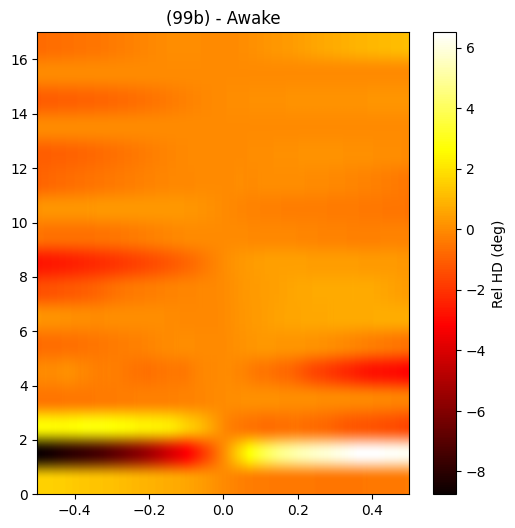

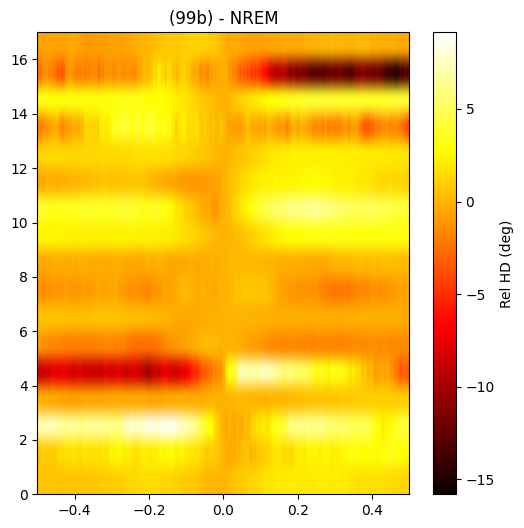

In [24]:

for sta in [sta_awake, sta_nrem]:
    zero_idx = np.where(sta.index == 0)[0].item()
    baseline = sta[zero_idx, :]
    sta_norm = sta - baseline
    plt.figure(figsize=(6, 6))
    im = plt.imshow(sta_norm.d[:, order].T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
    plt.colorbar(im, label='Rel HD (deg)')
    plt.title(f"({mouse_id}) - {'Awake' if sta is sta_awake else 'NREM'}")

(5361.0, 5381.0)

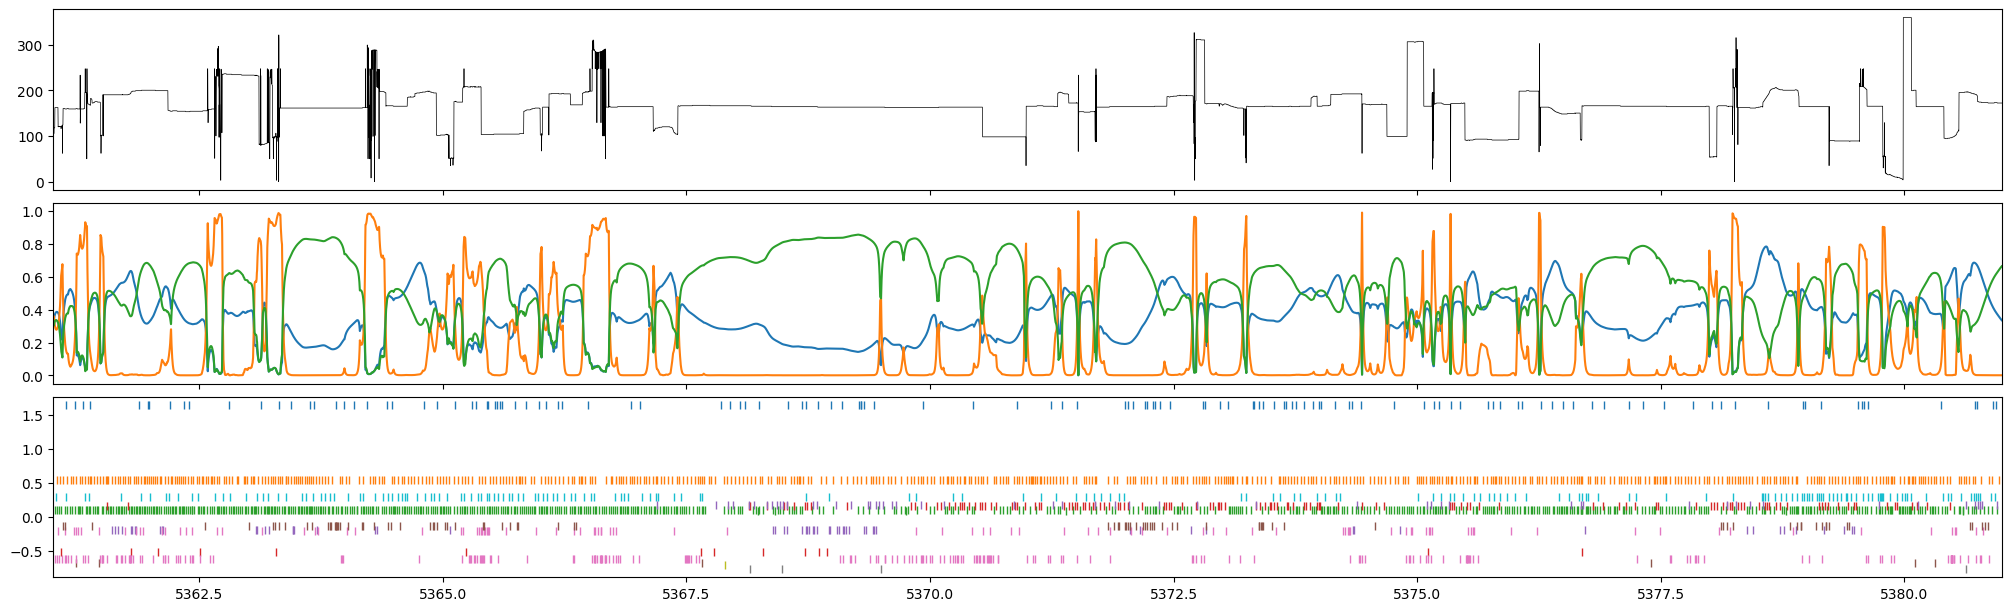

In [52]:
fig, axs = plt.subplots(3, 1, figsize=(20, 6), constrained_layout=True, sharex=True)
axs[0].plot(virtual_hd, color='k', linewidth=0.5)
axs[1].plot(states, label=STATE_NAMES)

for uid in turn_spikes:
    turn_index = turn_spikes['turn_index'][uid].item()
    axs[2].plot(turn_spikes[uid].fillna(turn_index), '|')

axs[0].set_xlim((ep.start, ep.start + 20))